# Train-Test Split

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

df=pd.read_csv("car_data_preprocessed.csv")
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [7]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (240, 12)
X_test  : (61, 12)
y_train : (240,)
y_test  : (61,)


# Random Forest Regression

In [10]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [12]:
rf.fit(X_train, y_train)
print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


# Model Prediction

In [14]:
# Predict selling prices
y_pred = rf.predict(X_test)

In [15]:
result = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

print(result.head(10))

     Actual Price  Predicted Price
177          0.35           0.4446
289         10.11          10.7398
228          4.95           4.9530
198          0.15           0.2192
60           6.95           7.9591
9            7.45           6.6665
118          1.10           1.1175
154          0.50           0.5912
164          0.45           0.4665
33           6.00           6.6625


# Model Evaluation

In [16]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

In [21]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 0.6016295081967212


In [17]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 0.7911840868852457


In [18]:
rmse = np.sqrt(mse)
print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 0.8894852932371876


In [19]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.9656538306554212


In [22]:
print("\nModel Evaluation")
print("------------------------")
print(f"MAE  : {mae:.3f}")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")


Model Evaluation
------------------------
MAE  : 0.602
MSE  : 0.791
RMSE : 0.889
R²   : 0.966


# Hyper parameter turning

In [24]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [25]:
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [26]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"ver

In [27]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [28]:
print("Best Cross Validation Score:")
print(grid_search.best_score_)

Best Cross Validation Score:
0.8807492756279978


In [29]:
best_rf = grid_search.best_estimator_

In [30]:
best_y_pred = best_rf.predict(X_test)

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, best_y_pred)
mse = mean_squared_error(y_test, best_y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, best_y_pred)

print("\nEvaluation After Hyperparameter Tuning")
print("--------------------------------------")
print(f"MAE  : {mae:.3f}")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")


Evaluation After Hyperparameter Tuning
--------------------------------------
MAE  : 0.615
MSE  : 0.806
RMSE : 0.898
R²   : 0.965


# Feature Importance

In [32]:
# Get feature importance
importance = best_rf.feature_importances_

In [33]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

In [34]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

             Feature  Importance
2      Present_Price    0.871621
8            Car_Age    0.032817
0           Car_Name    0.028054
1               Year    0.026931
3         Kms_Driven    0.025869
9   Mileage_per_Year    0.006337
6       Transmission    0.004540
7              Owner    0.001388
4          Fuel_Type    0.000964
5        Seller_Type    0.000747
11      High_Mileage    0.000727
10     Premium_Brand    0.000006


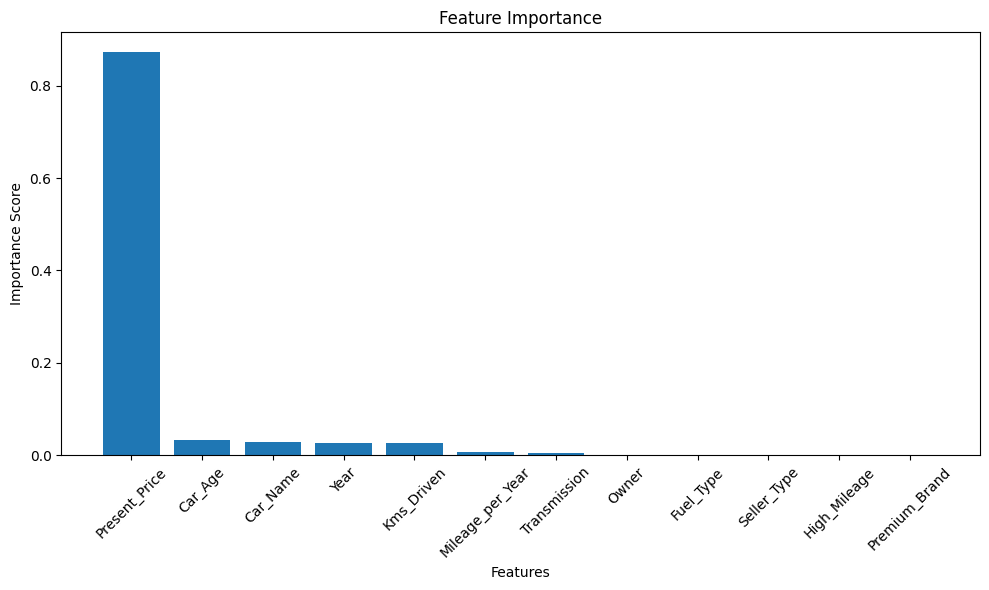

In [37]:
plt.figure(figsize=(10,6))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [38]:
print("Most Important Feature:")
print(feature_importance.iloc[0])

Most Important Feature:
Feature       Present_Price
Importance         0.871621
Name: 2, dtype: object


# SAVING MODEL

In [41]:
import joblib
joblib.dump(best_rf, "random_forest_model.joblib")

print("Model Saved Successfully!")

Model Saved Successfully!
